In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('bank-full.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

<Axes: xlabel='age', ylabel='Count'>

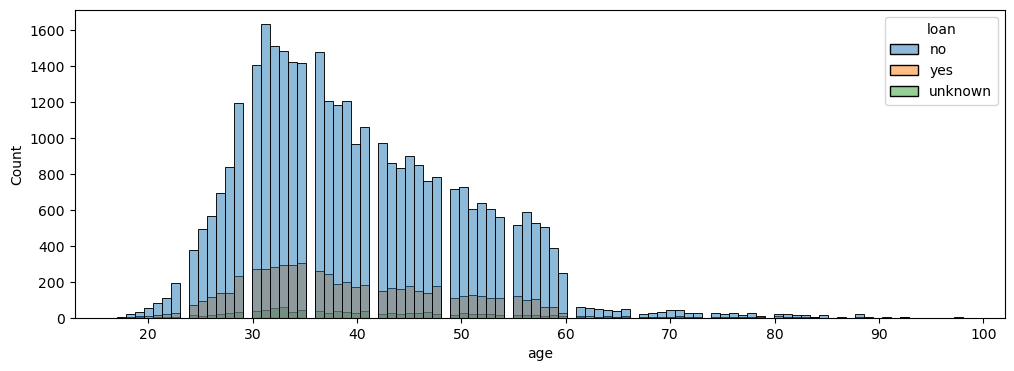

In [4]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='age',hue='loan')

<Axes: xlabel='pdays', ylabel='Count'>

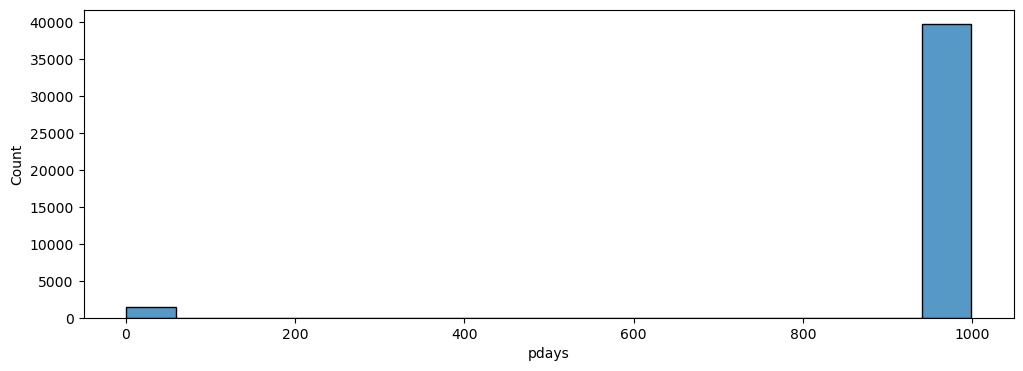

In [5]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='pdays')

In [7]:
df['pdays'].value_counts()

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

<Axes: xlabel='pdays', ylabel='Count'>

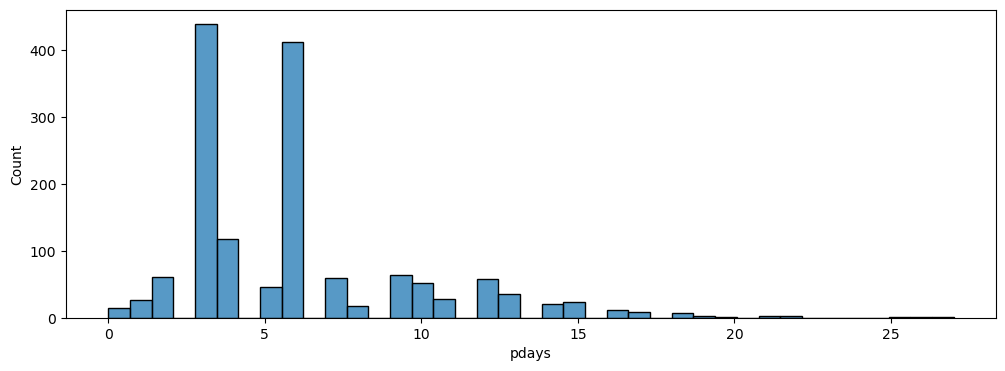

In [8]:
plt.figure(figsize=(12,4))
sns.histplot(data=df[df['pdays']!=999],x='pdays')

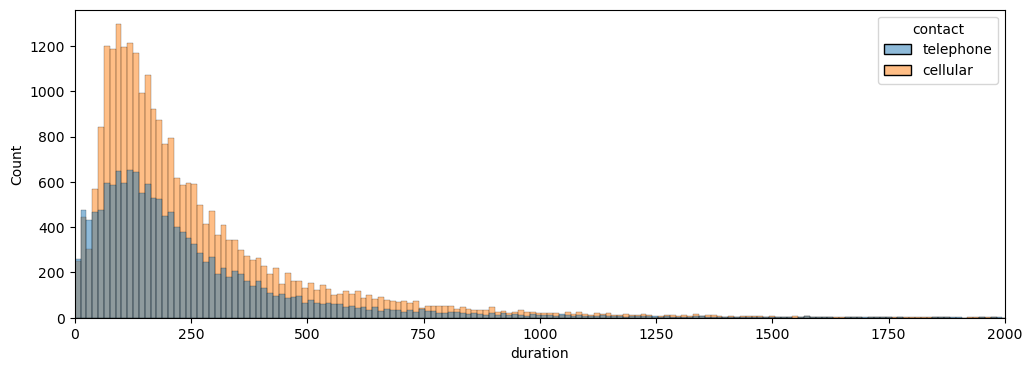

In [11]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='duration',hue='contact')
plt.xlim(0,2000)
plt.show()

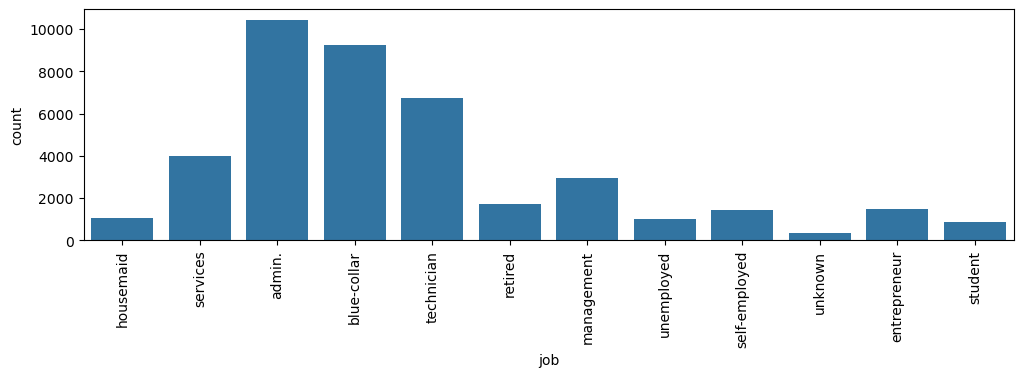

In [14]:
plt.figure(figsize=(12,3))
sns.countplot(data=df,x='job')
plt.xticks(rotation=90)
plt.show()

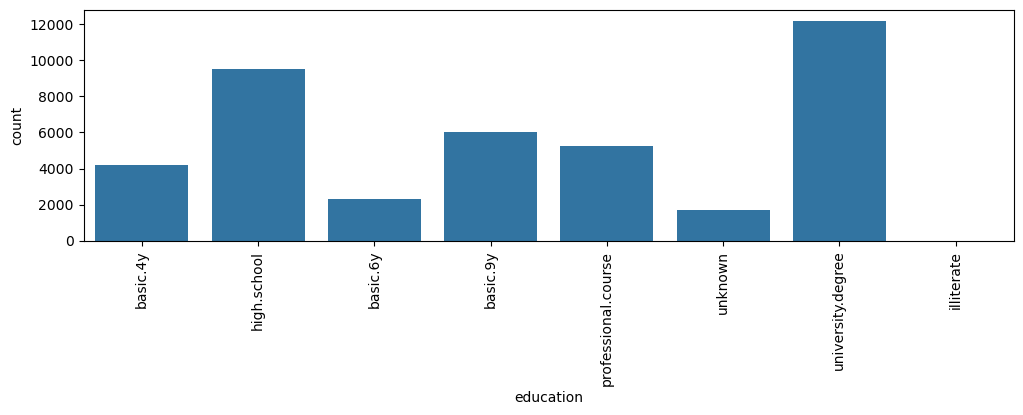

In [15]:
plt.figure(figsize=(12,3))
sns.countplot(data=df,x='education')
plt.xticks(rotation=90)
plt.show()

### Clustering

In [16]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [25]:
X= pd.get_dummies(df)
X.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False


In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
sc= StandardScaler()

In [28]:
sc_X= sc.fit_transform(X)

### KMeans Cluster

In [29]:
from sklearn.cluster import KMeans

In [30]:
model= KMeans(n_clusters=2)

In [34]:
cluster_labels=model.fit_predict(sc_X)

In [35]:
cluster_labels

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

In [36]:
len(cluster_labels)

41188

In [39]:
X['cluster']= cluster_labels

In [40]:
X.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes,cluster
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1


In [42]:
X.corr()['cluster']

age                    -0.071002
duration               -0.005265
campaign               -0.000411
pdays                   0.004278
previous               -0.008817
                          ...   
poutcome_nonexistent    0.004680
poutcome_success       -0.002890
subscribed_no           0.005330
subscribed_yes         -0.005330
cluster                 1.000000
Name: cluster, Length: 66, dtype: float64

In [43]:
X.corr()['cluster'].iloc[:-1]

age                    -0.071002
duration               -0.005265
campaign               -0.000411
pdays                   0.004278
previous               -0.008817
                          ...   
poutcome_failure       -0.003577
poutcome_nonexistent    0.004680
poutcome_success       -0.002890
subscribed_no           0.005330
subscribed_yes         -0.005330
Name: cluster, Length: 65, dtype: float64

<Axes: >

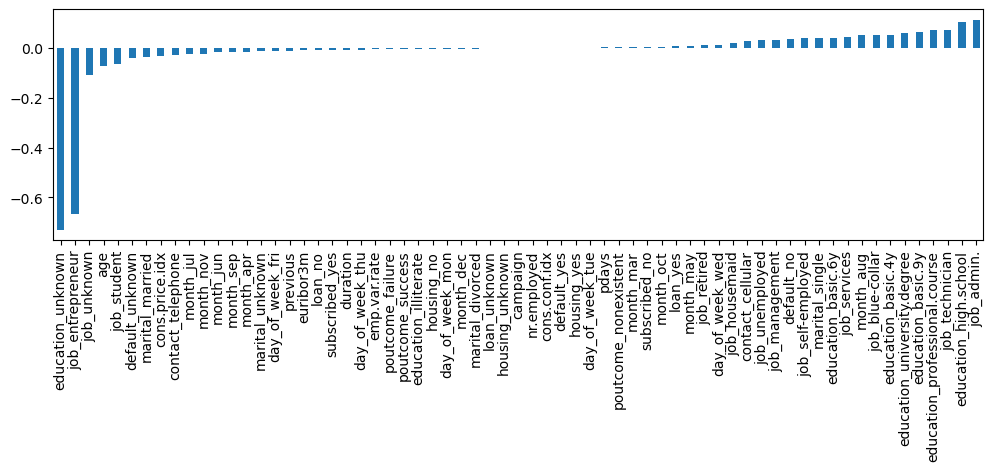

In [45]:
plt.figure(figsize=(12,3))
X.corr()['cluster'].iloc[:-1].sort_values().plot(kind='bar')